# Visualize Training Results

Use this notebook to inspect a training run folder from `runs/`. It can load `metrics.csv`, `config.json`, and available checkpoints, then plot loss and Dice curves.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

try:
    import ipywidgets as widgets
    from IPython.display import display
except ImportError:
    widgets = None

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RUNS_ROOT = PROJECT_ROOT / "runs"
RUNS_ROOT.mkdir(exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Runs root: {RUNS_ROOT}")

Project root: /home/basic/Faks/Automated-Cardiac-Diagnosis-Challenge
Runs root: /home/basic/Faks/Automated-Cardiac-Diagnosis-Challenge/runs


## Select Run Folder

In [2]:
def find_run_folders(runs_root):
    folders = []
    for folder in sorted(runs_root.iterdir()):
        if folder.is_dir() and (folder / "metrics.csv").exists():
            folders.append(folder)
    return folders


run_folders = find_run_folders(RUNS_ROOT)

if not run_folders:
    selected_run_dir = None
    print("No run folders with metrics.csv found yet.")
else:
    selected_run_dir = run_folders[-1]

    if widgets is None:
        print("ipywidgets is not available. Set selected_run_dir manually, for example:")
        print("selected_run_dir = RUNS_ROOT / 'fcn8_5epoch_gpu_bs16_lr1e-3'")
        print(f"Defaulting to latest folder: {selected_run_dir}")
    else:
        options = [(folder.relative_to(PROJECT_ROOT).as_posix(), folder) for folder in run_folders]
        dropdown = widgets.Dropdown(
            options=options,
            value=selected_run_dir,
            description="Run folder:",
            layout=widgets.Layout(width="700px"),
        )
        output = widgets.Output()

        def update_selected_run(change=None):
            global selected_run_dir
            selected_run_dir = dropdown.value
            with output:
                output.clear_output()
                print(f"Selected: {selected_run_dir.relative_to(PROJECT_ROOT)}")

        dropdown.observe(update_selected_run, names="value")
        display(dropdown, output)
        update_selected_run()

Dropdown(description='Run folder:', index=5, layout=Layout(width='700px'), options=(('runs/fcn8_100epoch_gpu_b…

Output()

## Load Metrics And Config

In [3]:
if selected_run_dir is None:
    raise RuntimeError("Select or create a run folder first.")

metrics_path = selected_run_dir / "metrics.csv"
config_path = selected_run_dir / "config.json"

metrics = pd.read_csv(metrics_path)
config = json.loads(config_path.read_text()) if config_path.exists() else {}

print(f"Loaded: {metrics_path.relative_to(PROJECT_ROOT)}")
print(f"Epochs logged: {len(metrics)}")
print(f"Device: {config.get('device', 'unknown')}")
print(f"Train files: {config.get('num_train_files', 'unknown')}")
print(f"Validation files: {config.get('num_val_files', 'unknown')}")

metrics.tail()

Loaded: runs/unet2d_200epoch_gpu_bs4_lr1e-4/metrics.csv
Epochs logged: 200
Device: cuda
Train files: 1538
Validation files: 374


,epoch,train_loss,train_pixel_accuracy,train_mean_foreground_dice,val_loss,val_pixel_accuracy,val_mean_foreground_dice,learning_rate,epoch_seconds,elapsed_seconds,elapsed_time,train_dice_class_0,train_dice_class_1,train_dice_class_2,train_dice_class_3,val_dice_class_0,val_dice_class_1,val_dice_class_2,val_dice_class_3
195,196,0.000128,0.999960,0.999275,0.228589,0.985679,0.817201,0.0001,102.985990,20281.207544,05:38:01,0.999988,0.999434,0.998883,0.999506,0.993367,0.800232,0.764187,0.887185
196,197,0.000125,0.999960,0.999266,0.225253,0.985814,0.819711,0.0001,102.995482,20384.570618,05:39:45,0.999988,0.999433,0.998899,0.999466,0.993452,0.808476,0.763130,0.887528
197,198,0.000164,0.999949,0.999072,0.242893,0.985388,0.813772,0.0001,103.030290,20487.949416,05:41:28,0.999985,0.999207,0.998673,0.999337,0.993140,0.805176,0.753980,0.882162
198,199,0.002068,0.999346,0.988591,0.180518,0.985606,0.815898,0.0001,102.969197,20591.282908,05:43:11,0.999780,0.988986,0.984459,0.992329,0.993358,0.806778,0.750957,0.889958
199,200,0.002011,0.999345,0.989531,0.137898,0.985639,0.816003,0.0001,103.020073,20694.675129,05:44:55,0.999736,0.982845,0.989924,0.995823,0.993430,0.805912,0.750460,0.891638


## Loss And Dice Curves

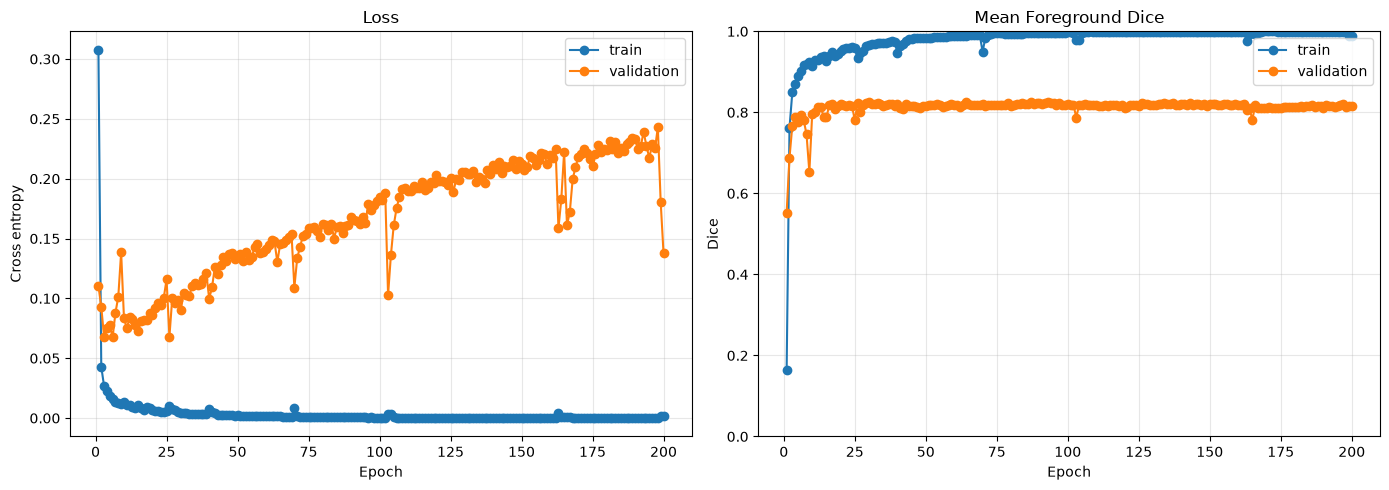

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(metrics["epoch"], metrics["train_loss"], marker="o", label="train")
axes[0].plot(metrics["epoch"], metrics["val_loss"], marker="o", label="validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross entropy")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(metrics["epoch"], metrics["train_mean_foreground_dice"], marker="o", label="train")
axes[1].plot(metrics["epoch"], metrics["val_mean_foreground_dice"], marker="o", label="validation")
axes[1].set_title("Mean Foreground Dice")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Dice")
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()

## Per-Class Dice

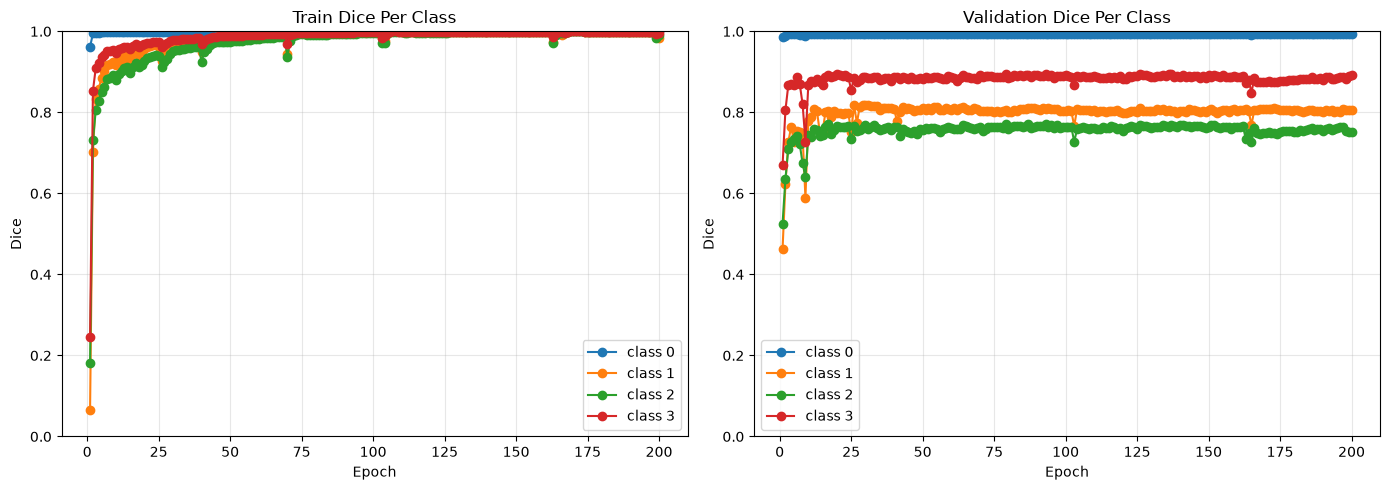

In [5]:
val_dice_columns = [column for column in metrics.columns if column.startswith("val_dice_class_")]
train_dice_columns = [column for column in metrics.columns if column.startswith("train_dice_class_")]

if not val_dice_columns:
    print("No per-class Dice columns found.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for column in train_dice_columns:
        class_id = column.rsplit("_", 1)[-1]
        axes[0].plot(metrics["epoch"], metrics[column], marker="o", label=f"class {class_id}")
    axes[0].set_title("Train Dice Per Class")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Dice")
    axes[0].set_ylim(0, 1)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    for column in val_dice_columns:
        class_id = column.rsplit("_", 1)[-1]
        axes[1].plot(metrics["epoch"], metrics[column], marker="o", label=f"class {class_id}")
    axes[1].set_title("Validation Dice Per Class")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Dice")
    axes[1].set_ylim(0, 1)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()

## Best Epoch Summary

In [6]:
best_index = metrics["val_mean_foreground_dice"].idxmax()
best_row = metrics.loc[best_index]

summary_columns = [
    "epoch",
    "train_loss",
    "train_mean_foreground_dice",
    "val_loss",
    "val_mean_foreground_dice",
    "epoch_seconds",
    "elapsed_time",
]
summary_columns = [column for column in summary_columns if column in metrics.columns]

print("Best validation Dice epoch:")
display(best_row[summary_columns].to_frame(name="value"))

Best validation Dice epoch:


,value
epoch,30
train_loss,0.004212
train_mean_foreground_dice,0.967158
val_loss,0.090141
val_mean_foreground_dice,0.825576
epoch_seconds,102.925597
elapsed_time,00:51:50


In [ ]:
best_index = metrics["val_mean_foreground_dice"].idxmax()
best_row = metrics.loc[best_index]
best_epoch = int(best_row["epoch"])

val_dice_columns = sorted(
    [column for column in metrics.columns if column.startswith("val_dice_class_")],
    key=lambda column: int(column.rsplit("_", 1)[-1]),
)

matching_best_weights = selected_run_dir / f"best_epoch_{best_epoch:03d}.pt"
best_weight_files = sorted(selected_run_dir.glob("best_epoch_*.pt"))

print(f"Best validation model epoch: {best_epoch}")
if matching_best_weights.exists():
    print(f"Best model weights: {matching_best_weights.relative_to(PROJECT_ROOT)}")
elif best_weight_files:
    print(f"Best model weights: {best_weight_files[-1].relative_to(PROJECT_ROOT)}")
else:
    print("Best model weights file not found in the selected run folder.")

if not val_dice_columns:
    print("No validation per-class Dice columns found.")
else:
    print("Validation Dice coefficients by class:")
    for column in val_dice_columns:
        class_id = column.rsplit("_", 1)[-1]
        print(f"  class {class_id}: {best_row[column]:.6f}")

## Checkpoints

In [7]:
checkpoint_rows = []
for checkpoint in sorted(selected_run_dir.glob("*.pt")):
    checkpoint_rows.append({
        "checkpoint": checkpoint.name,
        "size_mb": checkpoint.stat().st_size / (1024 * 1024),
        "path": checkpoint.relative_to(PROJECT_ROOT).as_posix(),
    })

if checkpoint_rows:
    display(pd.DataFrame(checkpoint_rows))
else:
    print("No checkpoint files found in this run folder.")

No checkpoint files found in this run folder.


## Run Configuration

In [8]:
if config:
    print(json.dumps(config, indent=2))
else:
    print("No config.json found in this run folder.")

{
  "args": {
    "data_dir": "outputs\\acdc_preprocessed_2d\\ACDC_training_slices",
    "run_dir": "runs\\unet2d_200epoch_gpu_bs4_lr1e-4",
    "weights": null,
    "epochs": 200,
    "batch_size": 4,
    "num_workers": 0,
    "num_classes": 4,
    "in_channels": 1,
    "base_channels": 64,
    "learning_rate": 0.0001,
    "beta1": 0.9,
    "beta2": 0.999,
    "weight_decay": 0.0,
    "val_fraction": 0.2,
    "seed": 42,
    "max_train_samples": null,
    "max_val_samples": null
  },
  "device": "cuda",
  "train_patients": [
    1,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    12,
    13,
    14,
    15,
    17,
    18,
    19,
    20,
    21,
    22,
    23,
    24,
    25,
    26,
    27,
    28,
    29,
    30,
    31,
    32,
    33,
    34,
    35,
    36,
    37,
    39,
    40,
    41,
    44,
    45,
    47,
    48,
    50,
    52,
    53,
    54,
    55,
    58,
    59,
    60,
    61,
    62,
    63,
    64,
    65,
    67,
    68,
    69,
    70,
    72,
    75,
    7